In [7]:
import csv
import re
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [8]:
def gaussian(x, x0, f):
    return f * np.exp(-(x - x0)**2 / (2 * sigma**2))
plt.style.use("default")

In [9]:
input_folder = os.path.join(os.getcwd(), "Input", "Uv_vis")
with open(os.path.join(input_folder, "Sheet1.csv")) as f:
    reader = csv.reader(f)
    x_std, y_std = zip(*reader)

# convert to numpy arrays of floats
x_std = np.array(x_std, dtype=float)
y_std = np.array(y_std, dtype=float)
y_std = y_std/np.max(y_std)

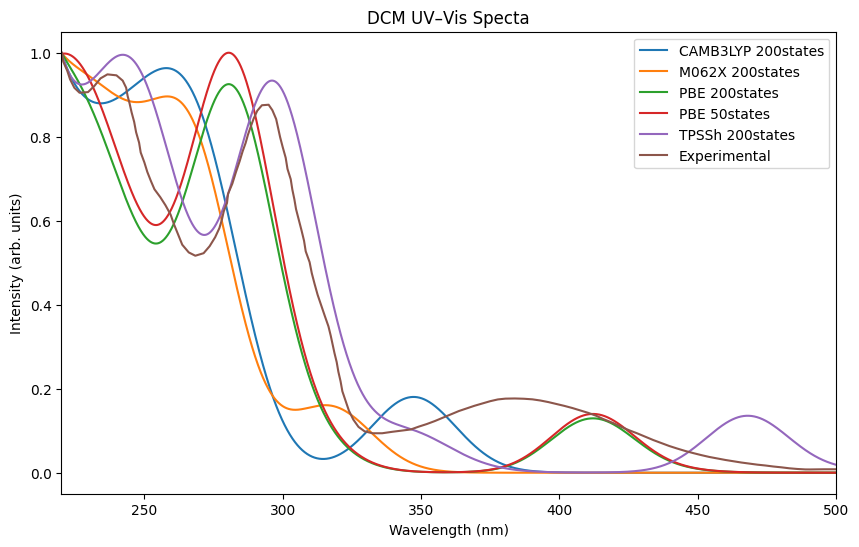

In [10]:
plt.figure(figsize=(10, 6))
x = np.linspace(150, 550, 5000)
mask = x >= 220
x_cut = x[mask]
for out_file in glob.glob(input_folder+"/*.out"):
    energies = []
    wavelengths = []
    osc = []
    with open(out_file) as f:
        for line in f:
            m = re.search(r"Excited State\s+\d+.*?([\d.]+)\s+eV\s+([\d.]+)\s+nm\s+f=([\d.]+)", line)
            if m:
                energies.append(float(m.group(1)))
                wavelengths.append(float(m.group(2)))
                osc.append(float(m.group(3)))
        energies = 1239.831765/np.array(energies)
        osc = np.array(osc)
        sigma = 15
        y = np.zeros_like(x)
        for e, f in zip(energies, osc):
            y += gaussian(x, e, f)  # convert nm grid to eV
        label = (os.path.splitext(os.path.basename(out_file))[0]).split('_')[3]+' '+(os.path.splitext(os.path.basename(out_file))[0]).split('_')[4]
        y_cut = y[mask]
        y_cut = y_cut/np.max(y_cut)
        x_cut = x_cut - 0
        plt.plot(x_cut, y_cut, label=label)
plt.plot(x_std, y_std, label="Experimental")
plt.xlim(220, 500)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (arb. units)")
plt.title("DCM UV–Vis Specta")
plt.legend()
plt.savefig(input_folder+"_overlap_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()


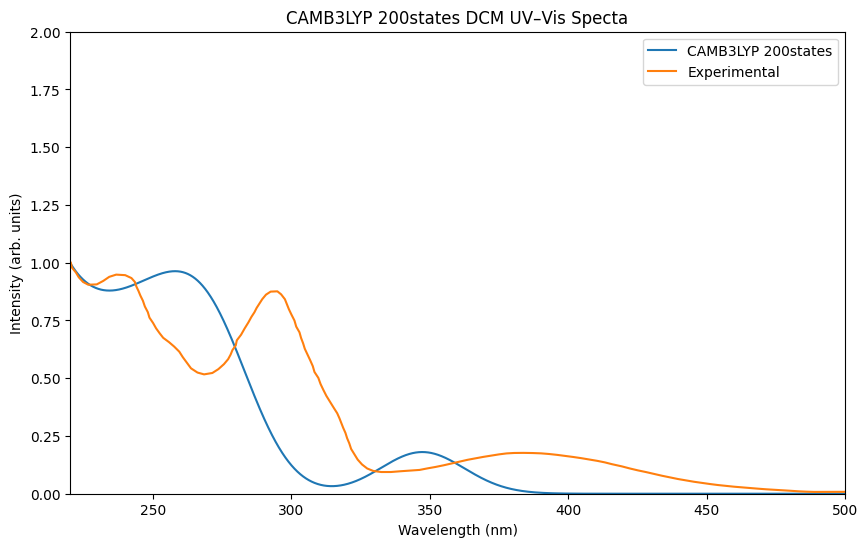

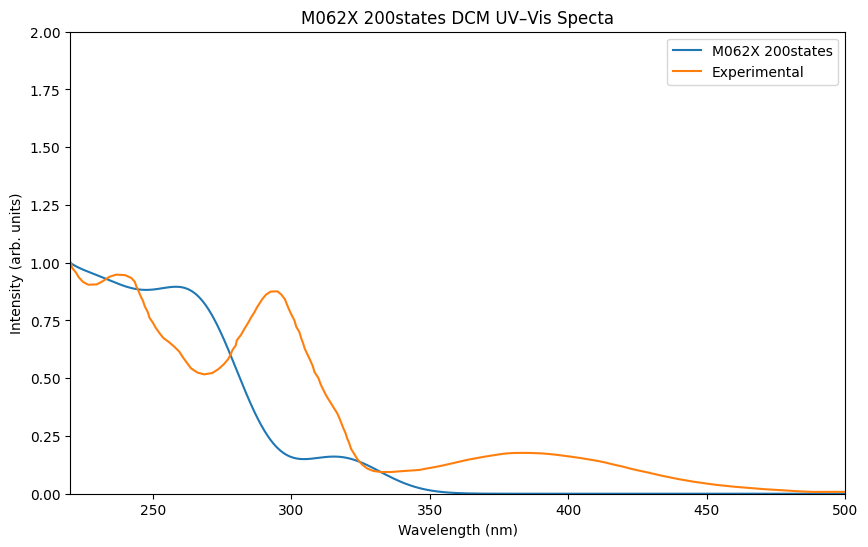

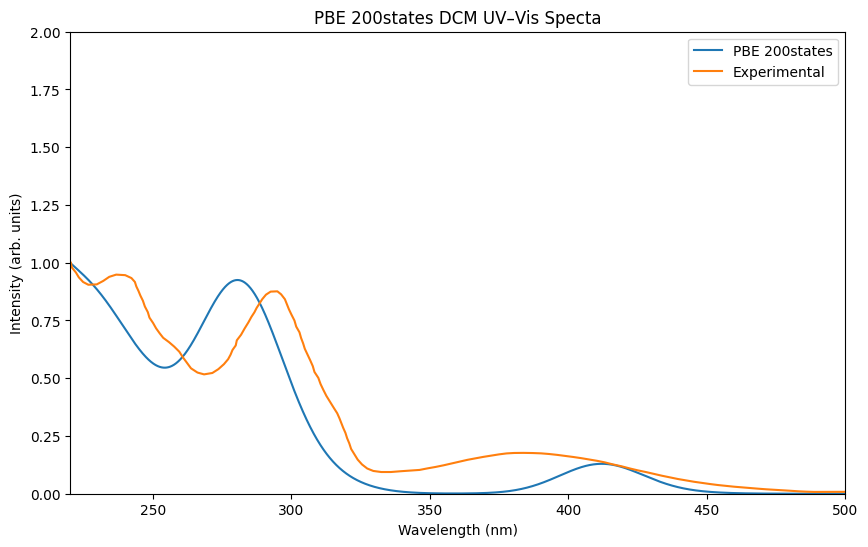

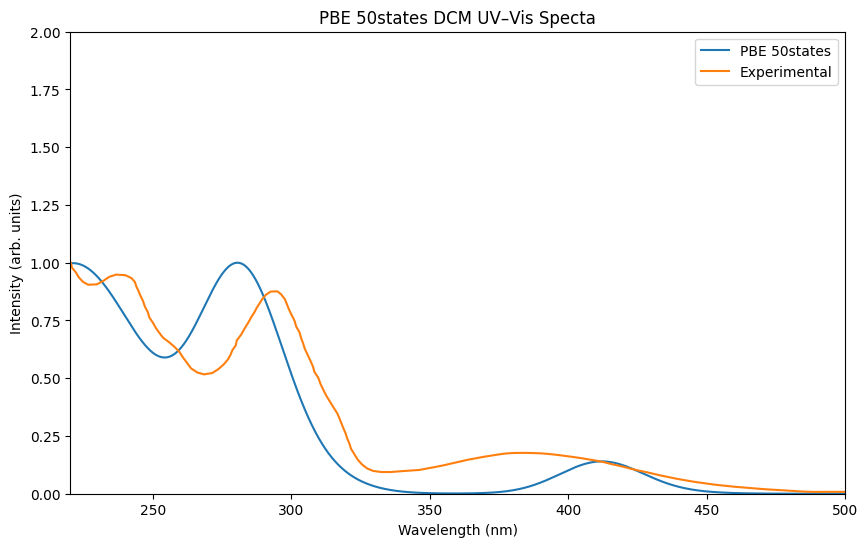

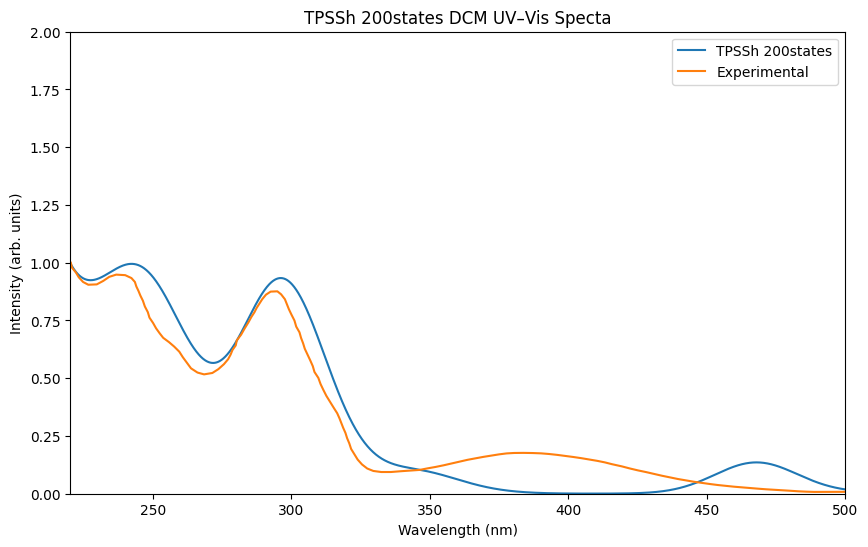

In [26]:
x = np.linspace(150, 550, 5000)
mask = x >= 220
x_cut = x[mask]
for out_file in glob.glob(input_folder+"/*.out"):
    energies = []
    wavelengths = []
    osc = []
    with open(out_file) as f:
        plt.figure(figsize=(10, 6))
        for line in f:
            m = re.search(r"Excited State\s+\d+.*?([\d.]+)\s+eV\s+([\d.]+)\s+nm\s+f=([\d.]+)", line)
            if m:
                energies.append(float(m.group(1)))
                wavelengths.append(float(m.group(2)))
                osc.append(float(m.group(3)))
        energies = 1239.831765/np.array(energies)
        osc = np.array(osc)
        sigma = 0.1
        y = np.zeros_like(x)
        sigma = 15
        y = np.zeros_like(x)
        for e, f in zip(energies, osc):
            y += gaussian(x, e, f)  # convert nm grid to eV
        label = (os.path.splitext(os.path.basename(out_file))[0]).split('_')[3]+' '+(os.path.splitext(os.path.basename(out_file))[0]).split('_')[4]
        y_cut = y[mask]
        y_cut = y_cut/np.max(y_cut)
        x_cut = x_cut
        plt.plot(x_cut, y_cut, label=label)
        x_cut = x_cut - 0
        plt.plot(x_std, y_std, label="Experimental")
        plt.xlim(220, 500)
        plt.ylim(0, 2)
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Intensity (arb. units)")
        plt.title(f"{(os.path.splitext(os.path.basename(out_file))[0]).split('_')[3]+' '+(os.path.splitext(os.path.basename(out_file))[0]).split('_')[4]} DCM UV–Vis Specta")
        plt.legend()
        plt.savefig(out_file.split(".")[0]+"single"+".png", dpi=300, bbox_inches="tight")
        plt.show()

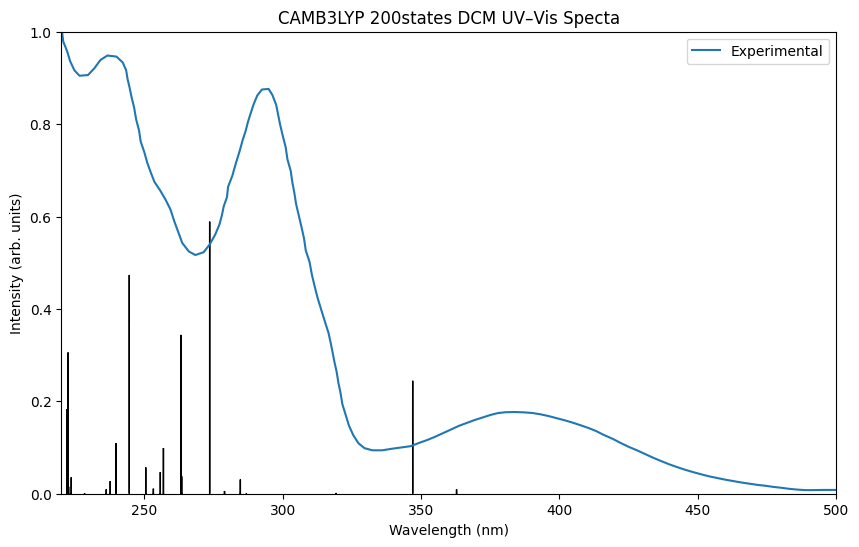

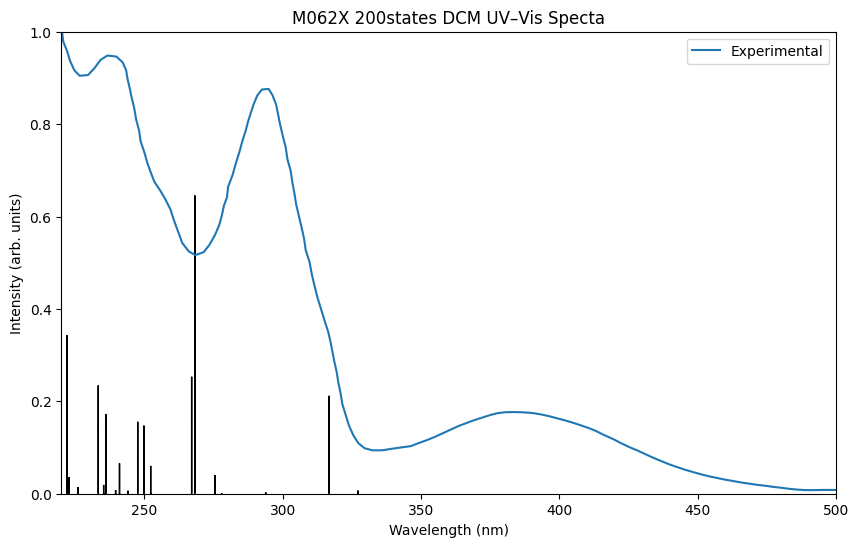

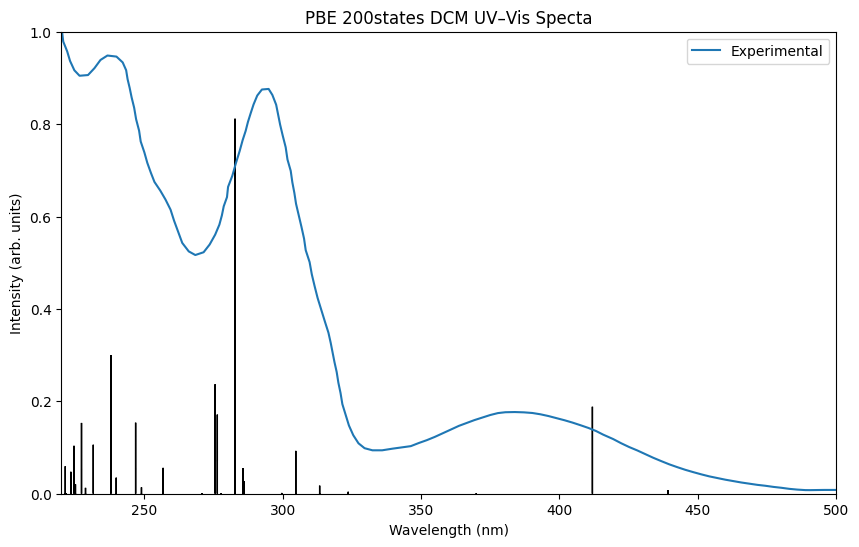

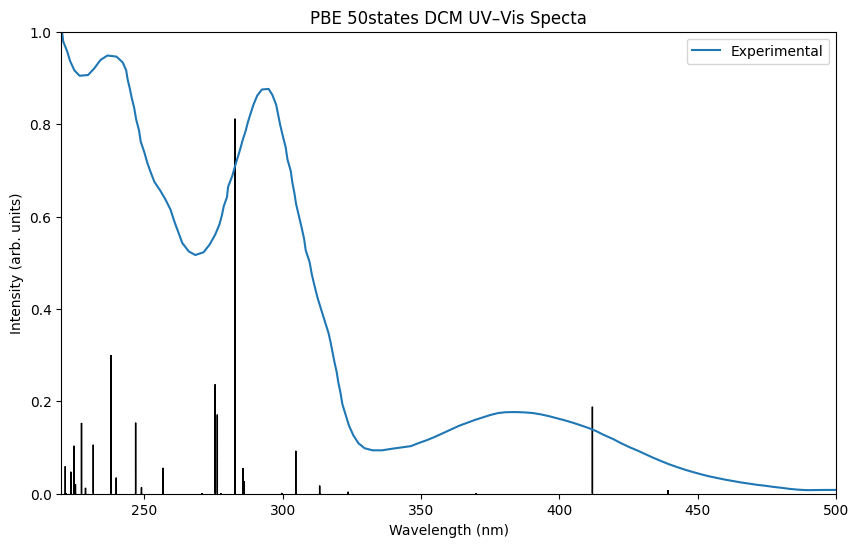

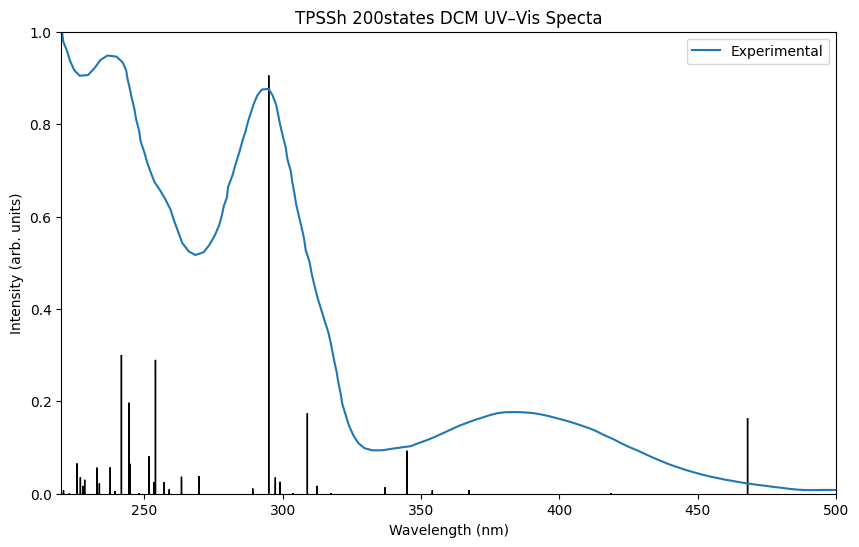

In [14]:
x = np.linspace(150, 550, 5000)
mask = x >= 220
x_cut = x[mask]
for out_file in glob.glob(input_folder+"/*.out"):
    energies = []
    wavelengths = []
    osc = []
    with open(out_file) as f:
        plt.figure(figsize=(10, 6))
        for line in f:
            m = re.search(r"Excited State\s+\d+.*?([\d.]+)\s+eV\s+([\d.]+)\s+nm\s+f=([\d.]+)", line)
            if m:
                energies.append(float(m.group(1)))
                wavelengths.append(float(m.group(2)))
                osc.append(float(m.group(3)))
        energies = 1239.831765/np.array(energies)
        osc = np.array(osc)
        sigma = 0.1
        y = np.zeros_like(x)
        for x0, h in zip(energies, osc):
            plt.arrow(x0, 0, 0, h*2.5,
                      head_width=0.03, head_length=0.1,
                      length_includes_head=True)
            label = (os.path.splitext(os.path.basename(out_file))[0]).split('_')[3]+' '+(os.path.splitext(os.path.basename(out_file))[0]).split('_')[4]
        x_cut = x_cut - 0
        plt.plot(x_std, y_std, label="Experimental")
        plt.xlim(220, 500)
        plt.ylim(0, 1)
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Intensity (arb. units)")
        plt.title(f"{(os.path.splitext(os.path.basename(out_file))[0]).split('_')[3]+' '+(os.path.splitext(os.path.basename(out_file))[0]).split('_')[4]} DCM UV–Vis Specta")
        plt.legend()
        plt.savefig(out_file.split(".")[0]+"spikes"+".png", dpi=300, bbox_inches="tight")
        plt.show()
